In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("olist.db")

pd.read_sql("""
SELECT name 
FROM sqlite_master 
WHERE type='table';
""", conn)

,name
0,customers
1,orders
2,order_items
3,products
4,payments
5,reviews


In [22]:
pd.read_sql("""
SELECT order_status, COUNT(*) as count
FROM orders
GROUP BY order_status
ORDER BY count DESC;
""", conn)

,order_status,count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [23]:
pd.read_sql("""
SELECT c.customer_state, COUNT(o.order_id) as total_orders
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_state
ORDER BY total_orders DESC;
""", conn)

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [24]:
pd.read_sql("""
SELECT AVG(payment_value) as avg_payment
FROM payments;
""", conn)

,avg_payment
0,154.10038


In [25]:
pd.read_sql("""
SELECT payment_type, COUNT(*) as count
FROM  payments
GROUP BY payment_type
ORDER BY count DESC;
""", conn)

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


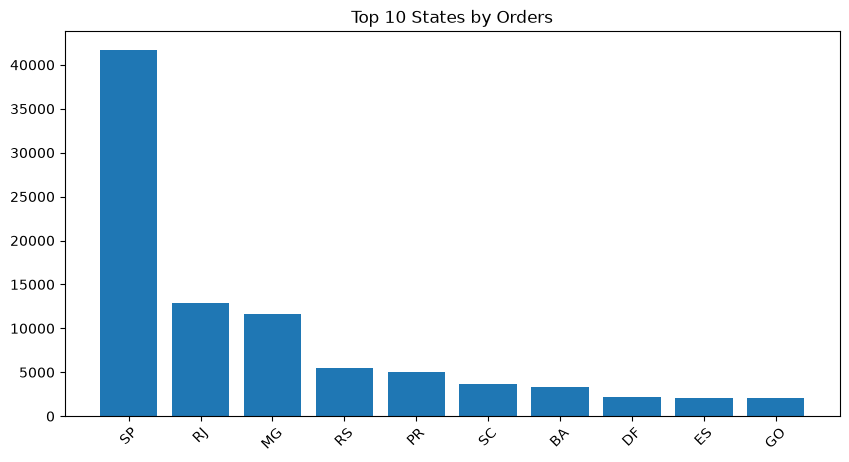

In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("olist.db")

pd.read_sql("""
SELECT name 
FROM sqlite_master 
WHERE type='table';
""", conn)
df = pd.read_sql("""
SELECT c.customer_state, COUNT(o.order_id) as total_orders
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_state
ORDER BY total_orders DESC
LIMIT 10;
""", conn)

plt.figure(figsize=(10,5))
plt.bar(df["customer_state"], df["total_orders"])
plt.title("Top 10 States by Orders")
plt.xticks(rotation=45)
plt.show()

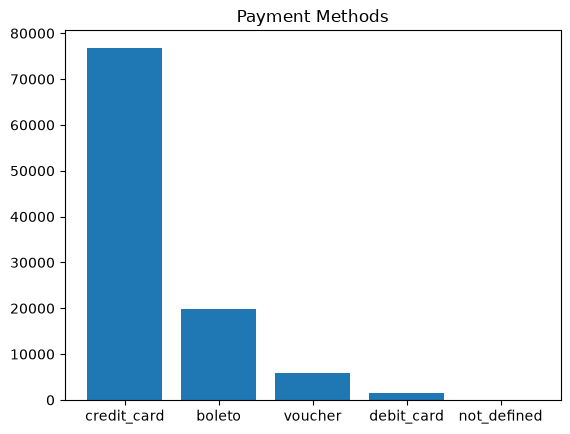

In [16]:
df = pd.read_sql("""
SELECT payment_type, COUNT(*) as count
FROM payments
GROUP BY payment_type
ORDER BY count DESC;
""", conn)

plt.figure()
plt.bar(df["payment_type"], df["count"])
plt.title("Payment Methods")
plt.show()

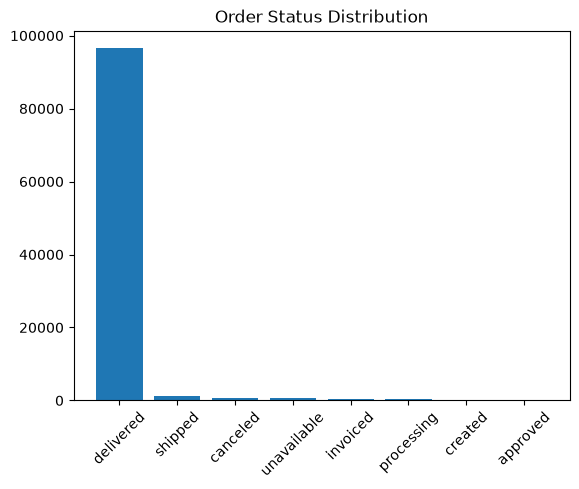

In [17]:
df = pd.read_sql("""
SELECT order_status, COUNT(*) as count
FROM orders
GROUP BY order_status
ORDER BY count DESC;
""", conn)

plt.figure()
plt.bar(df["order_status"], df["count"])
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()